# Qiskit 101
_**University of Technology - Qiskit Fall Fest - Sydney, NSW - 7 October 2026**_  
_Facilitator: Astri Cornish, IBM Quantum_



In this notebook you will learn how to program a quantum computer. You will walk through getting started with Qiskit, a [Qiskit Pattern](https://quantum.cloud.ibm.com/docs/en/guides/intro-to-patterns) workflow, and Qiskit's [Sampler primitive](https://docs.quantum.ibm.com/guides/get-started-with-primitives).

This notebook partially involves content from [IBM Quantum Documentation: Hello World](https://docs.quantum.ibm.com/guides/hello-world) and [Build and run your first quantum program](https://quantum.cloud.ibm.com/learning/en/courses/use-a-qc-today/build-and-run-your-first-quantum-program).

## Useful links
Links for today's workshop:
1. We will use a cloud-based platform to easily set up a coding environment with Qiskit. You may either use [Google Colab](https://colab.google/) (preferred) or [QBraid](https://www.qbraid.com/)
2. In Part D you will be asked to [create an IBM Cloud account](https://cloud.ibm.com/registration?utm_content=quantum-trial&target=https%3A%2F%2Fquantum.cloud.ibm.com&error_uri=) to access the [IBM Quantum Platform](https://quantum.cloud.ibm.com/) and its free quantum compute resources.
    - For those with a university email: [obtain a feature code here to extend your free trial period](https://github.com/academic-initiative/documentation/blob/main/academic-initiative/how-to/How-to-request-and-IBM-Cloud-Feature-Code/readme.md).
    - For those without a university email: [instructions to active your account](https://cloud.ibm.com/docs/account?topic=account-upgrading-account). Fully activate your account by registering a credit card. Your credit card is not charged in this process or at random after registering. This activation allows you to continue to access your free resources in the IBM Cloud and IBM Quantum platform after the trial period ends (30 days).

IBM Quantum:  
- [IBM Quantum use case studies](https://www.ibm.com/quantum/case-studies)
- [IBM Quantum Platform](https://quantum.cloud.ibm.com/)
- [IBM Quantum open plan: 10 free runtime minutes per month on IBM Quantum processors](https://quantum.cloud.ibm.com/docs/en/guides/plans-overview#open-plan).
- [PROMO: 180 free runtime minutes on IBM Quantum processors](https://www.ibm.com/quantum/blog/open-plan-updates)  

Education and Qiskit Community:  
- [Qiskit Ecosystem](https://www.ibm.com/quantum/ecosystem)  
- [IBM Quantum Learning](https://quantum.cloud.ibm.com/learning/en)  
- [Qiskit Global Summer School 2026 lectures](https://www.youtube.com/watch?v=X8YANoaMUGY&list=PLcYB0kKPI4a8)  
- [Qiskit v2.X Certification](https://www.ibm.com/training/certification/ibm-certified-quantum-computation-using-qiskit-v2x-developer-associate-C9008400)  
- [Qiskit advocate program](https://www.ibm.com/quantum/blog/qiskit-advocate-program)  

Stay in touch:  
- [Qiskit YouTube](https://www.youtube.com/qiskit)   
- [IBM Quantum LinkedIn](https://www.linkedin.com/showcase/ibm-quantum)  

## Part A: Installation and Set Up

### Install Qiskit <a id="install-qiskit"></a>



Today we will use an online jupyter lab environment (see guide [Online lab environments](https://quantum.cloud.ibm.com/docs/en/guides/online-lab-environments)), namely [Google Colab](https://colab.google/).

You can [install Qiskit locally](https://quantum.cloud.ibm.com/docs/en/guides/install-qiskit) - you may do this after this session.

Check that the version of Python you are using in your environment is python>=3.10, to make sure that it is compatible with the latest Qiskit version:

In [ ]:
from platform import python_version

print(python_version())

If you need to upgrade Python and are unsure how to do it, please refer to this guide on how to upgrade Python depending on your OS: [How to update Python](https://4geeks.com/how-to/how-to-update-python-version).

Now let's install Qiskit.

In [ ]:
%pip install qiskit[visualization]
%pip install qiskit-ibm-runtime
%pip install qiskit-aer

Now let's make the necessary imports for this workshop.

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import qiskit_ibm_runtime
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.executor_sampler import Sampler
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_vector, plot_bloch_multivector, plot_state_qsphere, plot_histogram
from IPython.display import display, Latex
import numpy as np
from numpy import pi


## Part B: Changing the quantum states of qubits and quantum systems <a id="build-circuits"></a>

#### How to create a quantum circuit with 1 qubit

We are going to first learn how to apply some operations to a qubit and visualise what happens when we do so.

**Demonstration:** Applying the X gate.

**Your go:** Try these gates that are available from the [circuit library in Qiskit](https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit_library), e.g. X, Y, H, Z, S, T. Also try applying multiple gates in a row and see what happens.

Some useful tools you may use alongside running Qiskit code:
- [Grok sphere](https://javafxpert.github.io/grok-bloch/)
- [IBM Quantum Composer](https://quantum.cloud.ibm.com/composer)

In [ ]:
# 1 - Create an empty quantum circuit with 1 qubit
qc = QuantumCircuit(1)

# 2 - Add gates and operations to the qubit
### YOUR CODE HERE ###

# 3 - Draw the output using MatPlotLib
qc.draw(output='mpl')


In [ ]:
# Print the statevector of the one-qubit quantum system
sv = Statevector(qc)
sv.draw(output='latex')


Note: How to read quantum statevectors, like the above.

Quantum statevector for one qubit:

${\alpha|0\rangle + \beta|1\rangle}$

where $\alpha$ and $\beta$ can be any arbitrary complex numbers whose squared moduli sum to 1, i.e. (|$\alpha$|)^2 + (|$\beta$|)^2 = 1

(|$\alpha$|)^2 and (|$\beta$|)^2 give the probabilities of measuring $|0\rangle$ and $|1\rangle$, respectively.


In [ ]:
# Visualise the state on a bloch sphere. X gate = 180 degree rotation counter-clockwise around the X axis.

sv.draw('bloch')

#### Superposition

**Quantum superposition:** the state in which a quantum particle or system can represent not just one possibility, but a combination of multiple possibilities simultaneously. It exists in this state until the system is measured or observed, at which point its state will collapse into one, definite state out of all the possibilities.

Let's see quantum superposition in action.

**Demonstration:** Creating equal superposition of the 0 and 1 states on the qubit.  

**Your go:** Create unequal superposition between the 1 and 0 states (more unequal than just statistical fluctuations).
Hints: use the [rx](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RXGate) or [ry](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RYGate) gates. We have already imported numpy as np. You may use pi from this.

In [ ]:
# Create quantum circuit with 1 qubit
qc_superposition = QuantumCircuit(1)

# Create superposition between the 0 and 1 states
### YOUR CODE HERE ###

# Draw the output using MatPlotLib
qc_superposition.draw(output='mpl')

In [ ]:
# Write out the system's statevector

sv_super = Statevector(qc_superposition)
sv_super.draw(output='latex')

In [ ]:
# Visualise on a bloch sphere

sv_super.draw('bloch')

In [ ]:
# Visualise output from a perfect quantum simulator

plot_histogram(sv_super.sample_counts(shots=1024))

#### How to create a quantum circuit with 2+ qubits

**Demonstration:** Applying an X gate to all qubits in a circuit. Applying a two-qubit gate (CX). Putting all qubits into equal superposition.

**Your go:** Try these gates that are available from the [circuit library in Qiskit](https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit_library), e.g. CNOT/CX, Toffoli/CCX, CY, SWAP.

In [ ]:
# Create a multi-qubit circuit
qc_multi = QuantumCircuit(2)

# Add gates and operations to the qubit/s
### YOUR CODE HERE ###

# Draw the output using MatPlotLib
qc_multi.draw(output='mpl')

In [ ]:
# Print the statevector of the quantum system
sv_multi = Statevector(qc_multi)
sv_multi.draw(output='latex')

In [ ]:
# Visualise the state on bloch spheres

sv_multi.draw('bloch')

In [ ]:
# Visualise output from a perfect quantum simulator

plot_histogram(sv_multi.sample_counts(shots=1024))

#### A note on bit numbering in Qiskit

 Qiskit numbers the bits in a string from right to left. The Qiskit SDK uses the LSb 0 bit numbering. When displaying or interpreting a list of $n$ bits (or qubits) as a string, bit $n−1$ is the leftmost bit, and bit $0$ is the rightmost bit. This is because we usually write numbers with the most significant digit on the left, and in Qiskit, bit $n−1$ is interpreted as the most significant bit. For more details, see the [Bit-ordering in the Qiskit SDK](https://docs.quantum.ibm.com/guides/bit-ordering) topic.



In [ ]:
#LSB ordering example

qc_lsb = QuantumCircuit(2)
qc_lsb.x(1)

qc_lsb.draw("mpl")

In [ ]:
sv_lsb = Statevector(qc_lsb)
sv_lsb.draw(output='latex')

#### Entanglement

**Quantum entanglement:** occurs when two or more qubits are intrinsically linked, such that one cannot describe the state of any qubit in the entangled system independently.

* Entangled qubits are correlated more strongly than classical probability allows.
* Operating on or collapsing one qubit instantly influences another qubit in the entangled system (although it never violates relativity).

Important gate for creating entanglement: Controlled-NOT gate (CNOT or CX).

CNOT/CX truth table:


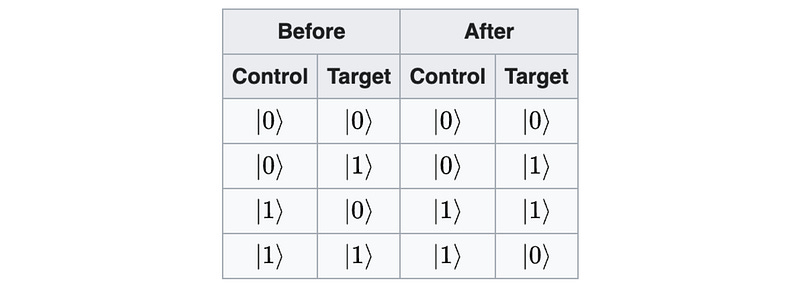

**Your go:** Entangle two qubits.

In [ ]:
#Let's entangle two qubits together

# 1 - Create a quantum circuit with two qubits
qc_entanglement = ## YOUR CODE HERE ##

# 2 - Put the first qubit into equal superposition between 0 and 1
## YOUR CODE HERE ##

# 3 - Entangle the two qubits with the CNOT gate (input 1 is the control; input 2 is the target)
## YOUR CODE HERE ##

# 4 - Draw the circuit
qc_entanglement.draw(output='mpl')

In [ ]:
# Write out the system's statevector

sv_entangle = Statevector(qc_entanglement)
sv_entangle.draw(output='latex')

In [ ]:
# Visualise on bloch spheres - what do you notice?

sv_entangle.draw('bloch')

**Why?** Remember that quantum entanglement occurs when two or more qubits are intrinsically linked, _such that one cannot describe the state of any qubit in the entangled system independently._

In [ ]:
# Visualise output from a perfect quantum simulator

plot_histogram(sv_entangle.sample_counts(shots=1024))

#### Interference

Quantum interference: occurs when two or more quantum amplitudes (associated with different possible paths or states) combine, leading to an enhancement or suppression of the total probability of an outcome due to their relative phase.

* Due to the wave-like nature of quantum particles
* Constructive interference: waves reinforce each other
* Destructive interference: waves cancel each other out
* Useful for algorithms like Grover’s where we want to amplify certain states and reduce others

**Demonstration:**  Let's first look at some procedures and gates that will introduce quantum phase into our one-qubit system.



In [ ]:
qc_inter = QuantumCircuit(1)
qc_inter.h(0) # put into superposition to see phase changes clearly
qc_inter.z(0) # introduce a phase of pi

qc_inter.draw("mpl")

In [ ]:
sv_inter = Statevector(qc_inter)
sv_inter.draw(output='latex')

In [ ]:
sv_inter.draw('bloch')

**Destructive and constructive interference demo**

First let's see what happens when we apply the H gate twice in a row.

In [ ]:
qc_inter_hh = QuantumCircuit(1)
qc_inter_hh.h(0)
qc_inter_hh.h(0)

qc_inter_hh.draw("mpl")

In [ ]:
sv_inter_hh = Statevector(qc_inter_hh)
sv_inter_hh.draw(output='latex')

What happens if we add quantum phase between the H gates?

In [ ]:
qc_inter_hzh = QuantumCircuit(1)
qc_inter_hzh.h(0)
qc_inter_hzh.z(0)
qc_inter_hzh.h(0)

qc_inter_hzh.draw("mpl")

In [ ]:
sv_inter_hzh = Statevector(qc_inter_hzh)
sv_inter_hzh.draw(output='latex')

In [ ]:
plot_histogram(sv_inter_hzh.sample_counts(shots=1024))

Adding phase between the H gates constructively amplified the 1 state and destructively reduced the possibility of measuring the 0 state - entirely such that the qubit now exists only in the 1 state.

What would happen if you chose gates that added different phases between the H gates?

#### Another way to create quantum circuits

In [ ]:
# Quantum circuit with a Quantum Register named 'qr' that has two qubits, and a Classical Register named 'cr' with two classical bits

# Create a quantum register with 2 qubits
qreg = QuantumRegister(2)

# Create a classical register with 2 bits
creg = ClassicalRegister(2)

# Create a quantum circuit with registers qreg and creg
qc = QuantumCircuit(qreg, creg)

# Add gates to your registers
qc.x(qreg)

# Draw the quantum circuit
qc.draw(output='mpl')

## Part C: Create and run a simple quantum algorithm using the Qiskit pattern framework <a id="qiskit-pattern"></a>


The Qiskit pattern conceptual framework can be considered the anatomy of a quantum algorithm.

The four steps to writing a quantum program using Qiskit patterns are:

1.  Map the problem to a quantum-native format.

2.  Optimize the circuits and operators.

3.  Execute using a Qiskit primitive function.

4.  Analyze the results.

### Step 1. Map the problem to a quantum-native format

In a quantum program, *quantum circuits* are the native format in which to represent quantum instructions, and *operators* represent the observables to be measured. When creating a circuit, you'll usually create a new [`QuantumCircuit`](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.QuantumCircuit#quantumcircuit-class) object, then add instructions to it in sequence.


### Exercise: <a id="build-circuits"></a>

<div class="alert alert-success">

Create a circuit for the Bell state $\frac{|01\rangle + |10\rangle}{\sqrt{2}}$

Do not add measurement gates yet.
</div>


In [ ]:
# Initialise circuit
qc = ## YOUR CODE HERE ##

# Add gates
## YOUR CODE HERE ##

# Return a drawing of the circuit using MatPlotLib ("mpl").
## YOUR CODE HERE ##


The initial state of the quantum circuit is the $|00\rangle$  state.

We can confirm we made the correct circuit by looking at the final state vector:

In [ ]:
# Use Statevector to fetch the statevector of the circuit
sv = Statevector(qc)
sv.draw(output='latex')

**Do we need measurement gates?**

When creating quantum circuits, you must also consider what type of data you want returned after execution. Qiskit provides two ways to return data: you can obtain the expectation value of an observable, or you can obtain a probability distribution for a set of qubits you choose to measure. Prepare your workload to measure your circuit in one of these two ways with [Qiskit primitives](https://docs.quantum.ibm.com/guides/get-started-with-primitives).


- `Sampler` primitive - returns a probability distribution for a set of qubits you choose to measure. E.g.:  
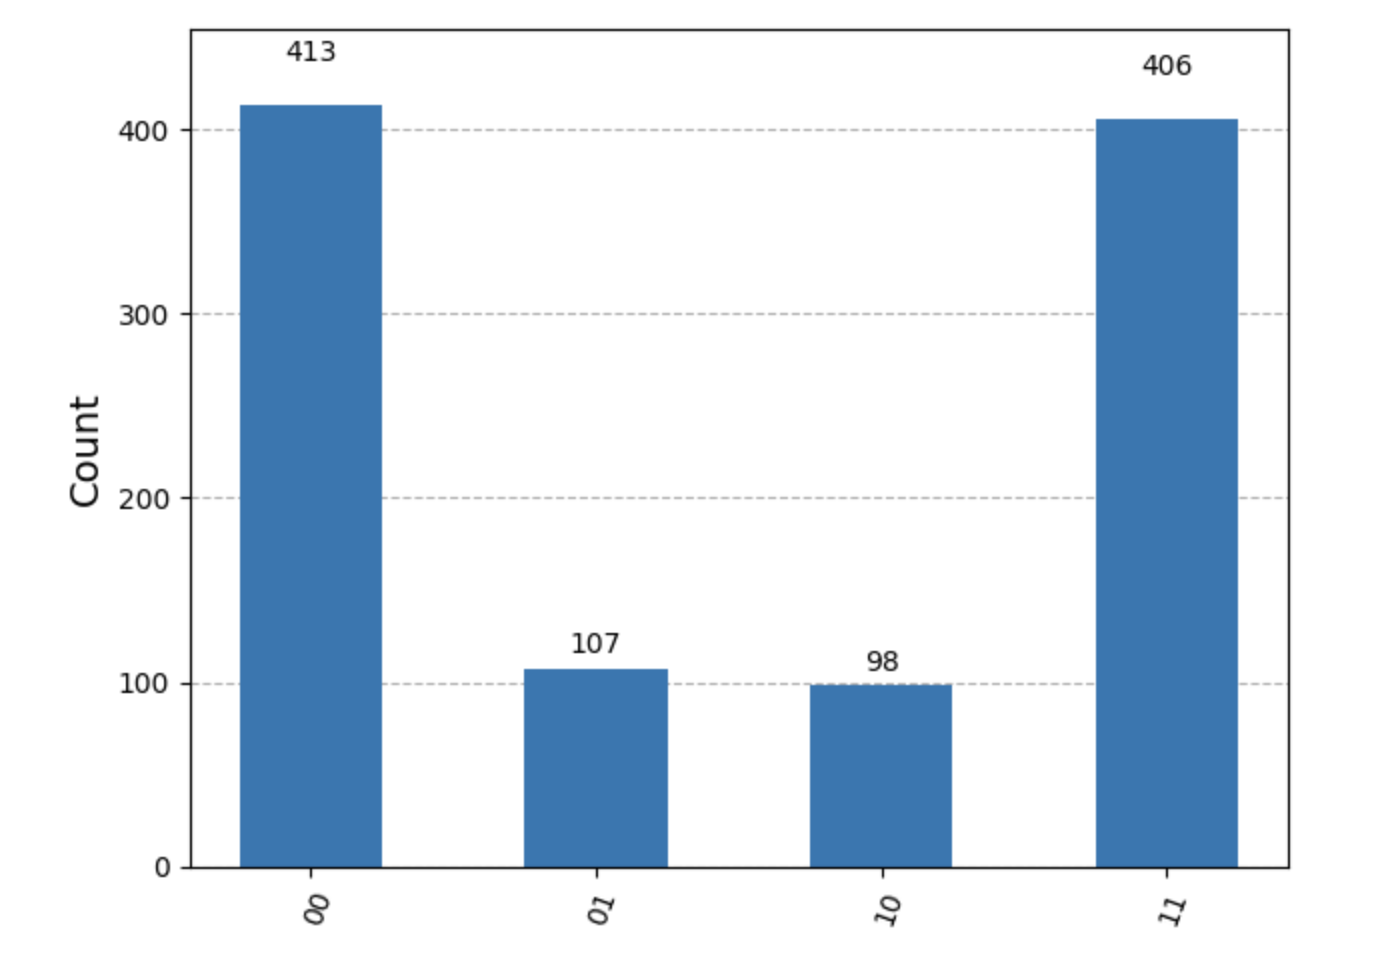

- `Estimator` primitive - returns the expectation value of an observable. E.g.:  
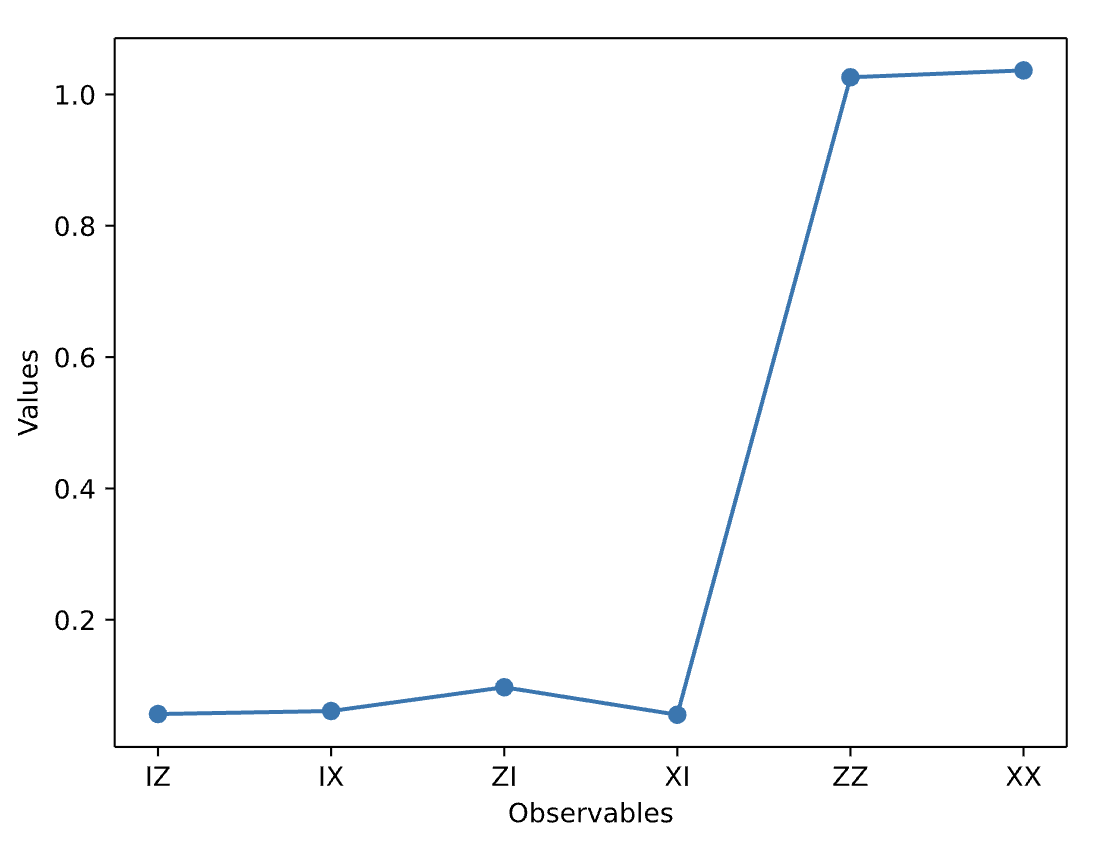




We'll be using the Sampler today, so we need to add measurement gates to our circuit.

In [ ]:
# Use measure_all, which adds a barrier, applies measurement gates on all qubits, creates a classical register called `meas`
qc.measure_all()
qc.draw('mpl')

### Step 2. Optimize the circuits for the target hardware

When executing circuits on a device, it is important to optimize the set of instructions that the circuit contains and minimize the overall depth (layers of operations) of the circuit. This ensures that you obtain the best results possible by reducing the effects of error and noise. Additionally, the circuit's instructions must conform to a backend device's [Instruction Set Architecture (ISA)](https://docs.quantum.ibm.com/guides/transpile#instruction-set-architecture) and must consider the device's basis gates and qubit connectivity.

The following code instantiates a simulator to submit a job to and transforms the circuit and observables to match that backend's ISA. Note that we will use a real device later.

In [ ]:
from qiskit_ibm_runtime.fake_provider import FakeTorino
backend = FakeTorino()

In [ ]:
print(
    f"Name: {backend.name}\n"
    f"Version: {backend.version}\n"
    f"Native gate set: {backend.operation_names}\n"
)

#to view other properties you can use properties()
# refer to https://docs.quantum.ibm.com/guides/get-qpu-information

In [ ]:
# Convert to an ISA circuit
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

isa_circuit_sampler = pm.run(qc)

isa_circuit_sampler.draw("mpl", idle_wires=False)

### Step 3. Execute using the Qiskit primitives

Quantum computers can produce random results, so you usually collect a sample of the outputs by running the circuit many times. You can estimate the value of the observable by using the `Estimator` class. `Sampler` can be used to get data from a quantum computer.  These objects possess a `run()` method that executes the selection of circuits, observables, and parameters (if applicable), using a [primitive unified bloc (PUB).](https://docs.quantum.ibm.com/guides/primitive-input-output#pubs)



In [ ]:
# Create a sampler instance using the selected backend
sampler = Sampler(backend)

# Run the sampler primitive on ISA circuit for specified number of shots (1024)

job_sampler = sampler.run([isa_circuit_sampler], shots=1024)

# Save the result of the job

result_sampler = job_sampler.result()

### Step 4. Post-process the results

This step involves postprocessing your results. You might feed these results into another workflow for further analysis or prepare a plot of the key values and data. In general, this step is specific to your problem.  

- For the `Sampler`, we plot the probability distribution obtained by sampling the quantum circuit as many times as the shots you specified using `plot_histogram`.

In [ ]:
from qiskit.visualization import plot_histogram

counts = result_sampler[0].data.meas.get_counts()
# Note: meas is the default name of the classical register when using measure_all().
# If you specify a classical register, then use the name you assign

# Plot the result
plot_histogram(counts)


## Part D: Run a program on a real device <a id="real-device"></a>

### Set up your IBM Quantum Platform account <a id="setting-ibm-cloud"></a>

In order to execute quantum circuits on real hardware, you will need an IBM Cloud account.

1. [Set up an IBM Cloud account](https://quantum.cloud.ibm.com/docs/en/guides/cloud-setup) if you do not already have one.
    - For those with a university email: [obtain a feature code here to extend your free trial period](https://github.com/academic-initiative/documentation/blob/main/academic-initiative/how-to/How-to-request-and-IBM-Cloud-Feature-Code/readme.md).
    - For those without a university email: [instructions to active your account](https://cloud.ibm.com/docs/account?topic=account-upgrading-account). Fully activate your account by registering a credit card. Your credit card is not charged in this process or at random after registering. This activation allows you to continue to access your free resources in the IBM Cloud and IBM Quantum platform after the trial period ends (30 days).
2. Log into or create an [IBM Quantum Platform](https://quantum.cloud.ibm.com/) account with an IBMid.

2. Access your IBM Quantum Platform dashboard, **create your API token**, and copy it to a secure location. (See first reference image below.)
3. In the code cell following the reference images, replace `deleteThisAndPasteYourAPIKeyHere` with your API key.
4. Go to the Instances page from the ☰ main menu and **create your instance**. If you are not part of a Network institution, choose the open plan. (See second reference image below.)
5. After the instance is created, copy its associated CRN code. (CRN stands for _Cloud Resource Names_) You may need to refresh to see the instance.
6.  In the code cell following the reference images, replace `deleteThisAndPasteYourCRNHere` with your CRN code.


 **Note:** Treat your API key as you would a secure password. Refer to the [Set up your IBM Cloud account](https://quantum.cloud.ibm.com/docs/guides/cloud-setup#cloud-save) guide for more information about using your API key in both secure and untrusted environments.




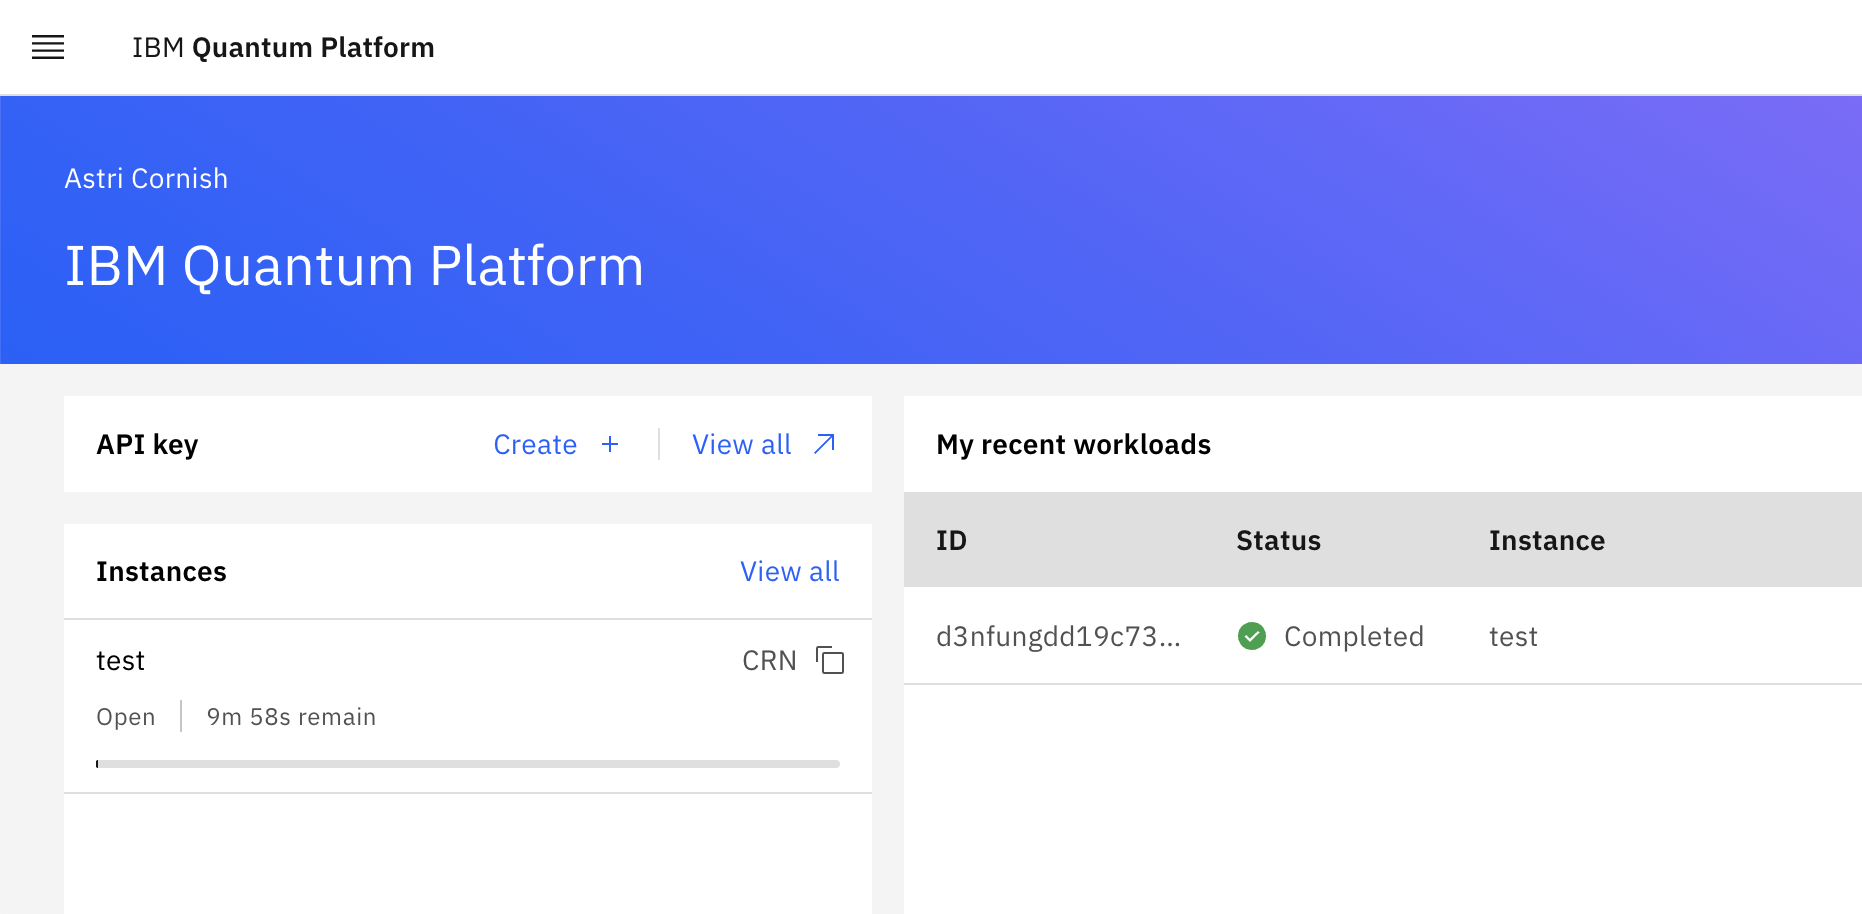

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
# Save your API key to access real devices

your_api_key = "your_api_key"
your_crn = "your_crn"

QiskitRuntimeService.save_account(
    channel="ibm_cloud",
    token=your_api_key,
    instance=your_crn,
    set_as_default=True,
    overwrite=True,
)

 If you'd like to run our circuit from Part C on a real device, you can use the following code.



In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

# View the list of backends you have access to

service = QiskitRuntimeService()

service.backends()

In [ ]:
# Get backend
backend_real = service.least_busy(simulator=False, operational=True)

#backend_real = service.backend(name="insert_backend_name") # use this if you want to choose a specific backend

sampler = Sampler(backend_real)

pm = generate_preset_pass_manager(backend=backend_real, optimization_level=3)
isa_circuit = pm.run(qc)

job = sampler.run([isa_circuit], shots=1024)


In [ ]:
print(job.job_id)

In [ ]:
print(
    f"Name: {backend_real.name}\n"
    f"Version: {backend_real.version}\n"
    f"Native gate set: {backend_real.operation_names}\n"
)

In [ ]:
result = job.result()

In [ ]:
counts = result[0].data.meas.get_counts()

plot_histogram(counts)

### Fetching results from a completed job

The cell below demonstrates how you can fetch results from a completed job.

In [ ]:
service = QiskitRuntimeService()
retrieved_job = service.job('job_id') # paste in your job id here
result = retrieved_job.result()
counts = result[0].data.meas.get_counts()
plot_histogram(counts)